j0= 3.2654523609624974e-06


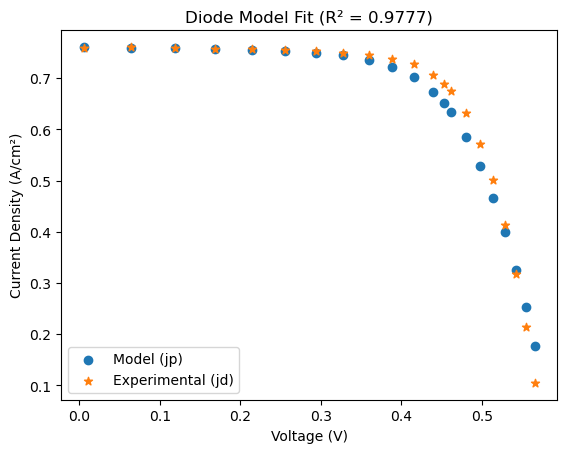

In [1]:
#Now we have a good enough first approximation for the model
#First let's modify the value of j0, by varying the exponent by 10^(-0.1) and not going beyond, say 10^(-8)

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.optimize import fsolve

def diode_eq(jp, vd, j0, jph, Rs, Rsh, m):
    return jph - j0*(np.exp(q*(vd+jp*Rs)/(m*k*T)) - 1)-vd/Rsh-jp

data = pd.read_csv('RTC France Si Solar Cell.csv')
vd=data['V_cell']
jd=data['J_cell']

q = 1.602e-19
k = 1.3806e-23
T = 298

jph=0.7611
Rsh=40.697
Rs=0.063
m=1.862

a=4
j0=1.3*10**(-1*a)
r2=-100
af=4

for i in range(40):
    a=a+0.1
    j0=1.3*10**(-1*a)
    jp = np.array([fsolve(diode_eq, jph, args=(v, j0, jph, Rs, Rsh, m))[0] for v in vd])
    ss_res = np.sum((jd - jp) ** 2)
    ss_tot = np.sum((jd - np.mean(jd)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    #print(r_squared, a)
    if(r_squared>r2):
        af=a
        r2=r_squared
j0=1.3*10**(-1*af)
jp = np.array([fsolve(diode_eq, jph, args=(v, j0, jph, Rs, Rsh, m))[0] for v in vd])
print("j0=", j0)
plt.scatter(vd, jp, label="Model (jp)", marker='o')
plt.scatter(vd, jd, label="Experimental (jd)", marker='*')
plt.xlabel("Voltage (V)")
plt.ylabel("Current Density (A/cm²)")
plt.legend()
plt.title(f"Diode Model Fit (R² = {r2:.4f})")
plt.show()


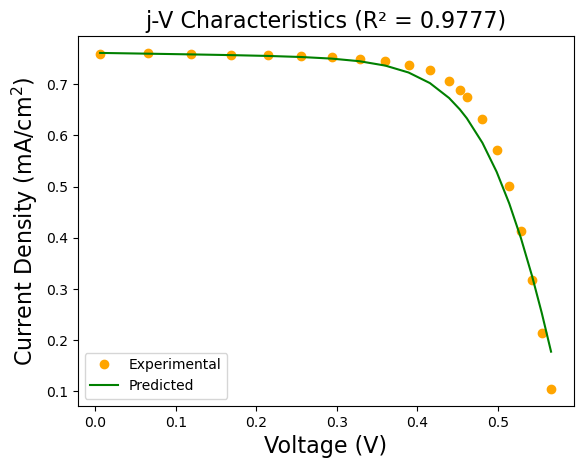

In [ ]:
#Now the parameters
# Rsh=40.697 ohm
# Rs=0.063 ohm
# m=1.862 ohm
# j0=3.265*10^(-6) A/cm^2

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.optimize import fsolve

def diode_eq(jp, vd, j0, jph, Rs, Rsh, m):
    return jph - j0*(np.exp(q*(vd+jp*Rs)/(m*k*T)) - 1)-vd/Rsh-jp

data = pd.read_csv('RTC France Si Solar Cell.csv')
vd=data['V_cell']
jd=data['J_cell']

q = 1.602e-19
k = 1.3806e-23
T = 298

jph=0.7611
Rsh=40.697
Rs=0.063
m=1.862
j0=3.265*10**(-6)
jp = np.array([fsolve(diode_eq, jph, args=(v, j0, jph, Rs, Rsh, m))[0] for v in vd])
plt.plot(vd, jd, 'o', label='Experimental', color='orange')
plt.plot(vd, jp, color='green', label='Predicted')
plt.xlabel('Voltage (V)', fontsize='16')
plt.ylabel('Current Density (A/cm$^2$)', fontsize='16')
plt.title(f"j-V Characteristics (R² = {r2:.4f})", fontsize='16')
plt.legend()
plt.show()

[3.625, 0.063, 40.697, 1.862]
Iteration 0: R² = 0.97813
[ 2.84619114  0.06105121 39.67300441  1.82687411]
Iteration 1: R² = 0.98278
[ 2.22739699  0.05945427 38.89018307  1.79264153]
Iteration 2: R² = 0.98588
[ 1.74697433  0.05814544 38.30393687  1.7598808 ]
Iteration 3: R² = 0.98777
[ 1.37970507  0.05706818 37.87587347  1.72901442]
Iteration 4: R² = 0.98884
[ 1.10142576  0.05617313 37.57348549  1.70032008]
Iteration 5: R² = 0.98941
[ 0.89128124  0.05541821 37.36961339  1.67394688]
Iteration 6: R² = 0.98974
[ 0.73240758  0.05476857 37.24185585  1.64993599]
Iteration 7: R² = 0.99001
[ 0.61174045  0.05419624 37.17197912  1.62824426]
Iteration 8: R² = 0.99030
[ 0.51943926  0.05367953 37.14534214  1.60876802]
Iteration 9: R² = 0.99066
[ 0.44821977  0.05320216 37.15034808  1.59136479]
Iteration 10: R² = 0.99111
[ 0.39274065  0.05275229 37.17793461  1.57587114]
Iteration 11: R² = 0.99162
[ 0.34909873  0.05232162 37.22111416  1.56211628]
Iteration 12: R² = 0.99218
[ 0.31443875  0.05190455 37.2

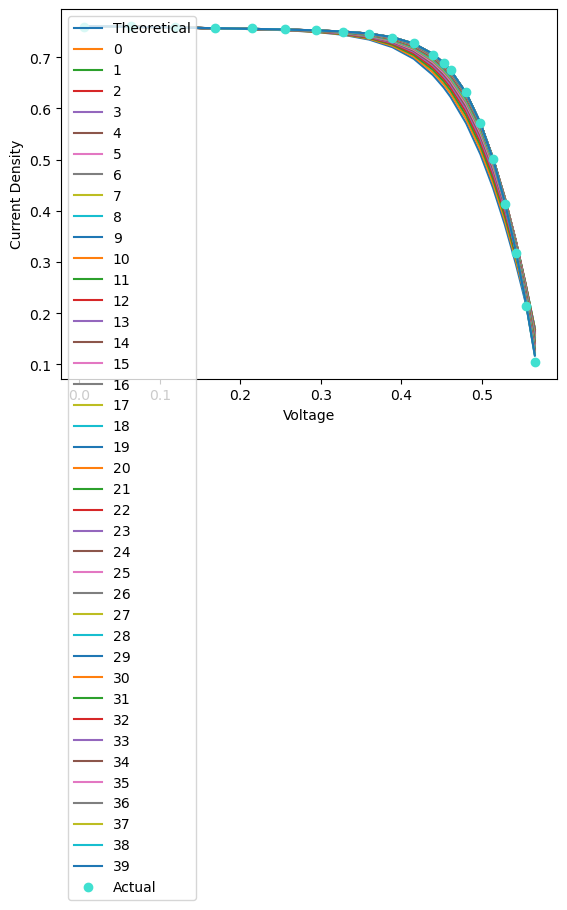

In [3]:
#Now using the Jacobian Matrix
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.optimize import fsolve

def diode_eq(jp, vd, j0, jph, Rs, Rsh, m):
    return jph - j0*(np.exp(q*(vd+jp*Rs)/(m*k*T)) - 1)-vd/Rsh-jp

def Jmat(jp, vd, k1, Rs, Rsh, m):
    J=[0, 0, 0, 0]
    J[0]=-10**(-6)*(np.exp(q/(m*k*T)*(vd+Rs*jp))-1)
    J[1]=-k1*10**(-6)*np.exp(q/(m*k*T)*(vd+Rs*jp))*(q*jp/(m*k*T))
    J[2]=vd/(Rsh**2)
    J[3]=k1*10**(-6)*np.exp(q/(m*k*T)*(vd+Rs*jp))*(q/(m*m*k*T)*(vd+Rs*jp))
    return J
data = pd.read_csv('RTC France Si Solar Cell.csv')
vd=data['V_cell']
jd=data['J_cell']

q = 1.602e-19
k = 1.3806e-23
T = 298

jph=0.7611
Rsh=40.697
Rs=0.063
m=1.862
k1=3.625
j0=k1*10**(-6)

#residuals
jp = np.array([fsolve(diode_eq, jph, args=(v, j0, jph, Rs, Rsh, m))[0] for v in vd])
R=jd-jp
P=[k1, Rs, Rsh, m]
plt.plot(vd, jp, label='Theoretical')
for i in range(40):
    print(P)
    J=Jmat(jp, vd, k1, Rs, Rsh, m)
    J1=np.dot(J, np.transpose(J))
    delP=-1*np.dot(np.linalg.inv(J1), np.dot(J, R))
    alpha=0.1
    P=P-alpha*delP
    k1=P[0]
    Rs=P[1]
    Rsh=P[2]
    m=P[3]
    j0=k1*10**(-6)
    jp = np.array([fsolve(diode_eq, jph, args=(v, j0, jph, Rs, Rsh, m))[0] for v in vd])
    plt.plot(vd, jp, label=i)
    R=jd-jp
    R2 = 1 - np.sum(R**2) / np.sum((jd - np.mean(jd))**2)
    print(f"Iteration {i}: R² = {R2:.5f}")
plt.plot(vd, jd, 'o', label='Actual', color='turquoise')
#plt.plot(vd, jp, label='Theoretical')
plt.xlabel('Voltage')
plt.ylabel('Current Density')
plt.legend()
plt.show()

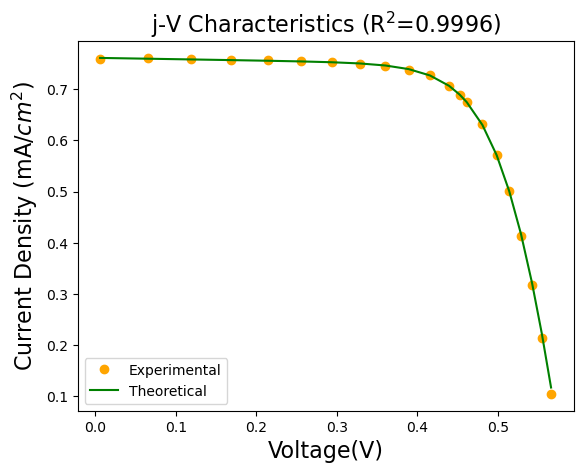

In [4]:
plt.plot(vd, jd, 'o', label='Experimental', color='orange')
#plt.plot(vd, jp, label='Theoretical')
plt.plot(vd, jp, label='Theoretical', color='green')
plt.xlabel('Voltage(V)', fontsize='16')
plt.ylabel('Current Density (mA/$cm^2$)', fontsize='16')
plt.title('j-V Characteristics (R$^2$=0.9996)', fontsize='16')
plt.legend()
plt.show()